In [18]:
import os
import pandas as pd

folder = r"C:\DOCUMENTO\站点_20210101-20211231\20210101-20211231"
reference_file = os.path.join(folder, "china_sites_20210316.csv")

site_alias = {
    "1475A": "workers_hospital_decommissioned_20181115",
    "1476A": "lanlian_hotel",
    "1477A": "yuzhong_lzu_campus_control",
    "1478A": "biological_products_institute",
    "1479A": "railway_design_institute",
}

# Scientific-conservative interpolation rule:
# only fill short internal gaps (<=2 consecutive hours), keep long gaps as NaN.
SHORT_GAP_LIMIT = 2


def parse_mixed_date(series):
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y%m%d", errors="coerce")
    miss = dt.isna()
    if miss.any():
        dt2 = pd.to_datetime(s[miss], errors="coerce")
        dt.loc[miss] = dt2
    return dt


header_cols = pd.read_csv(reference_file, nrows=0).columns
target_sites = [site_id for site_id in site_alias if site_id in header_cols]
missing_sites = [site_id for site_id in site_alias if site_id not in header_cols]
if missing_sites:
    print("Missing site columns in reference file:", missing_sites)

daily_files = sorted(
    f for f in os.listdir(folder)
    if f.startswith("china_sites_") and f.endswith(".csv")
)

site_frames = {site_id: [] for site_id in target_sites}
base_cols = ["date", "hour", "type"]
required_cols = set(base_cols + target_sites)

for file_name in daily_files:
    file_path = os.path.join(folder, file_name)
    df = pd.read_csv(file_path, usecols=lambda c: c in required_cols)
    if not required_cols.issubset(df.columns):
        continue

    for site_id in target_sites:
        site_frames[site_id].append(df[base_cols + [site_id]])

for site_id, frames in site_frames.items():
    if not frames:
        print(f"No valid rows found for {site_id}")
        continue

    long_df = pd.concat(frames, ignore_index=True)
    wide_df = (
        long_df.pivot_table(
            index=["date", "hour"],
            columns="type",
            values=site_id,
            aggfunc="first",
        )
        .reset_index()
        .sort_values(["date", "hour"])
    )
    wide_df.columns.name = None

    # ----- Apply short-gap interpolation directly on hourly wide data -----
    wide_df["date"] = parse_mixed_date(wide_df["date"])
    wide_df["hour"] = pd.to_numeric(wide_df["hour"], errors="coerce")
    wide_df = wide_df.dropna(subset=["date", "hour"]).copy()
    if wide_df.empty:
        print(f"Skip {site_id}: no valid date/hour rows after parsing")
        continue

    wide_df["hour"] = wide_df["hour"].astype(int)
    wide_df["datetime"] = wide_df["date"] + pd.to_timedelta(wide_df["hour"], unit="h")
    wide_df = wide_df.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates(subset=["datetime"]).copy()
    if wide_df.empty:
        print(f"Skip {site_id}: datetime is empty after cleanup")
        continue

    # Rebuild full hourly axis so structural missing hours can be identified
    start_dt = wide_df["datetime"].min()
    end_dt = wide_df["datetime"].max()
    if pd.isna(start_dt) or pd.isna(end_dt):
        print(f"Skip {site_id}: start/end datetime is NaT")
        continue

    full_index = pd.date_range(start=start_dt, end=end_dt, freq="h")
    if len(full_index) == 0:
        print(f"Skip {site_id}: empty date_range from {start_dt} to {end_dt}")
        continue

    wide_df = (
        wide_df.set_index("datetime")
        .reindex(full_index)
        .rename_axis("datetime")
        .reset_index()
    )

    value_cols = [c for c in wide_df.columns if c not in ["datetime", "date", "hour"]]

    # Count missing before interpolation
    missing_before = {c: int(pd.to_numeric(wide_df[c], errors="coerce").isna().sum()) for c in value_cols}

    # Time-based interpolation: only short internal gaps
    wide_df = wide_df.set_index("datetime")
    for c in value_cols:
        wide_df[c] = pd.to_numeric(wide_df[c], errors="coerce")
        wide_df[c] = wide_df[c].interpolate(
            method="time",
            limit=SHORT_GAP_LIMIT,
            limit_direction="both",
            limit_area="inside",
        )
    wide_df = wide_df.reset_index()

    # Restore date/hour format for compatibility with downstream notebooks
    wide_df["date"] = wide_df["datetime"].dt.strftime("%Y%m%d").astype(int)
    wide_df["hour"] = wide_df["datetime"].dt.hour.astype(int)
    wide_df = wide_df[["date", "hour"] + value_cols].sort_values(["date", "hour"]).reset_index(drop=True)

    missing_after = {c: int(wide_df[c].isna().sum()) for c in value_cols}
    filled_short = {c: missing_before[c] - missing_after[c] for c in value_cols}

    output_name = f"{site_id}_{site_alias[site_id]}_yearly_wide.csv"
    output_path = os.path.join(folder, output_name)
    wide_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"Saved: {output_path}")
    print(f"  Interp summary (limit={SHORT_GAP_LIMIT}h, long gaps kept NaN):")
    print("  ", {k: v for k, v in filled_short.items() if v > 0})


Skip 1475A: no valid date/hour rows after parsing
Saved: C:\DOCUMENTO\站点_20210101-20211231\20210101-20211231\1476A_lanlian_hotel_yearly_wide.csv
  Interp summary (limit=2h, long gaps kept NaN):
   {'AQI': 284, 'CO': 137, 'CO_24h': 59, 'NO2': 167, 'NO2_24h': 59, 'O3': 156, 'O3_24h': 59, 'O3_8h': 83, 'O3_8h_24h': 61, 'PM10': 204, 'PM10_24h': 59, 'PM2.5': 211, 'PM2.5_24h': 59, 'SO2': 150, 'SO2_24h': 59}
Saved: C:\DOCUMENTO\站点_20210101-20211231\20210101-20211231\1477A_yuzhong_lzu_campus_control_yearly_wide.csv
  Interp summary (limit=2h, long gaps kept NaN):
   {'AQI': 291, 'CO': 193, 'CO_24h': 59, 'NO2': 178, 'NO2_24h': 55, 'O3': 153, 'O3_24h': 55, 'O3_8h': 83, 'O3_8h_24h': 57, 'PM10': 170, 'PM10_24h': 55, 'PM2.5': 168, 'PM2.5_24h': 55, 'SO2': 150, 'SO2_24h': 55}
Saved: C:\DOCUMENTO\站点_20210101-20211231\20210101-20211231\1478A_biological_products_institute_yearly_wide.csv
  Interp summary (limit=2h, long gaps kept NaN):
   {'AQI': 349, 'CO': 311, 'CO_24h': 76, 'NO2': 233, 'NO2_24h': 80, '

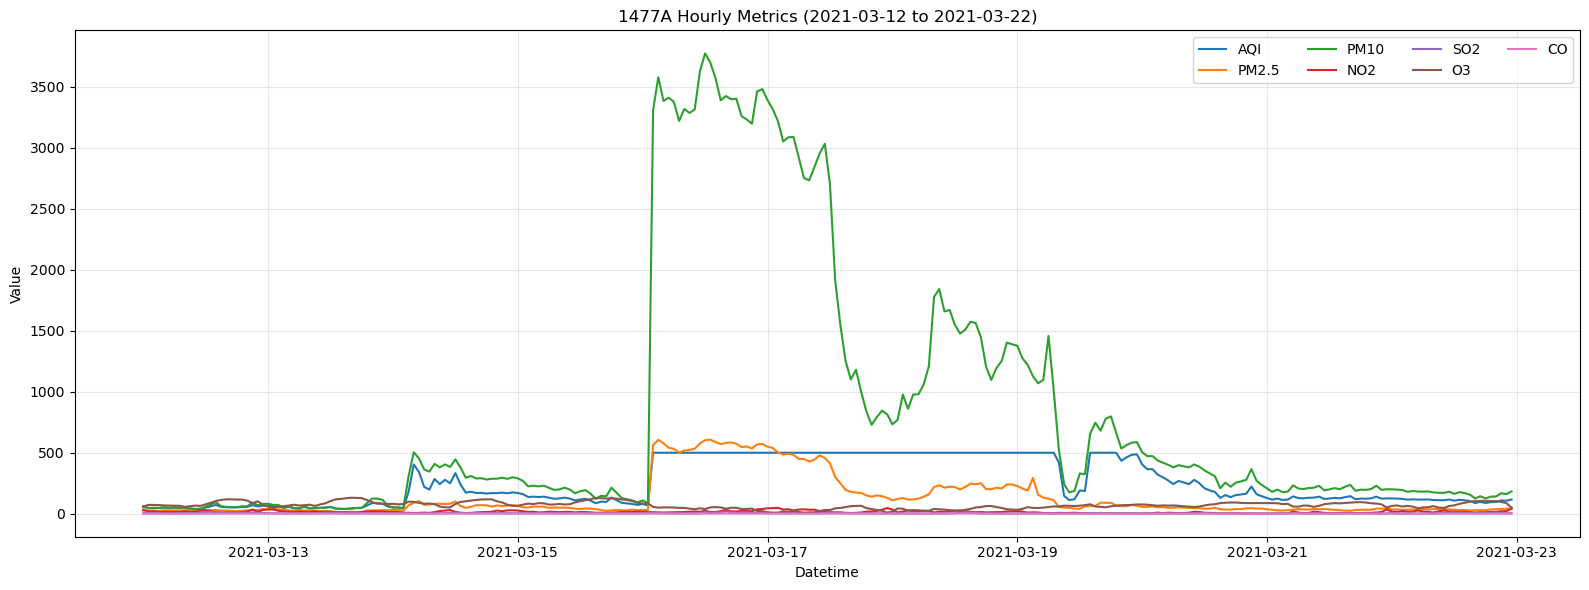

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder = r"C:\DOCUMENTO\站点_20210101-20211231\20210101-20211231"
site_file = os.path.join(folder, "1477A_yuzhong_lzu_campus_control_yearly_wide.csv")

df = pd.read_csv(site_file)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")

start = pd.Timestamp("2021-03-12 00:00:00")
end = pd.Timestamp("2021-03-22 23:00:00")
plot_df = df[(df["datetime"] >= start) & (df["datetime"] <= end)].copy()

metrics = ["AQI", "PM2.5", "PM10", "NO2", "SO2", "O3", "CO"]
metrics = [m for m in metrics if m in plot_df.columns]

# Only short-gap interpolation for each variable (scientific conservative):
# fill at most 2 consecutive missing points; long gaps remain NaN.
plot_df = plot_df.sort_values("datetime").set_index("datetime")
for metric in metrics:
    plot_df[metric] = pd.to_numeric(plot_df[metric], errors="coerce")
    plot_df[metric] = plot_df[metric].interpolate(
        method="time",
        limit=2,
        limit_direction="both",
        limit_area="inside",
    )
plot_df = plot_df.reset_index()

plt.figure(figsize=(16, 6))
for metric in metrics:
    plt.plot(plot_df["datetime"], plot_df[metric], label=metric, linewidth=1.5)

plt.title("1477A Hourly Metrics (2021-03-12 to 2021-03-22)")
plt.xlabel("Datetime")
plt.ylabel("Value")
plt.legend(ncol=4)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


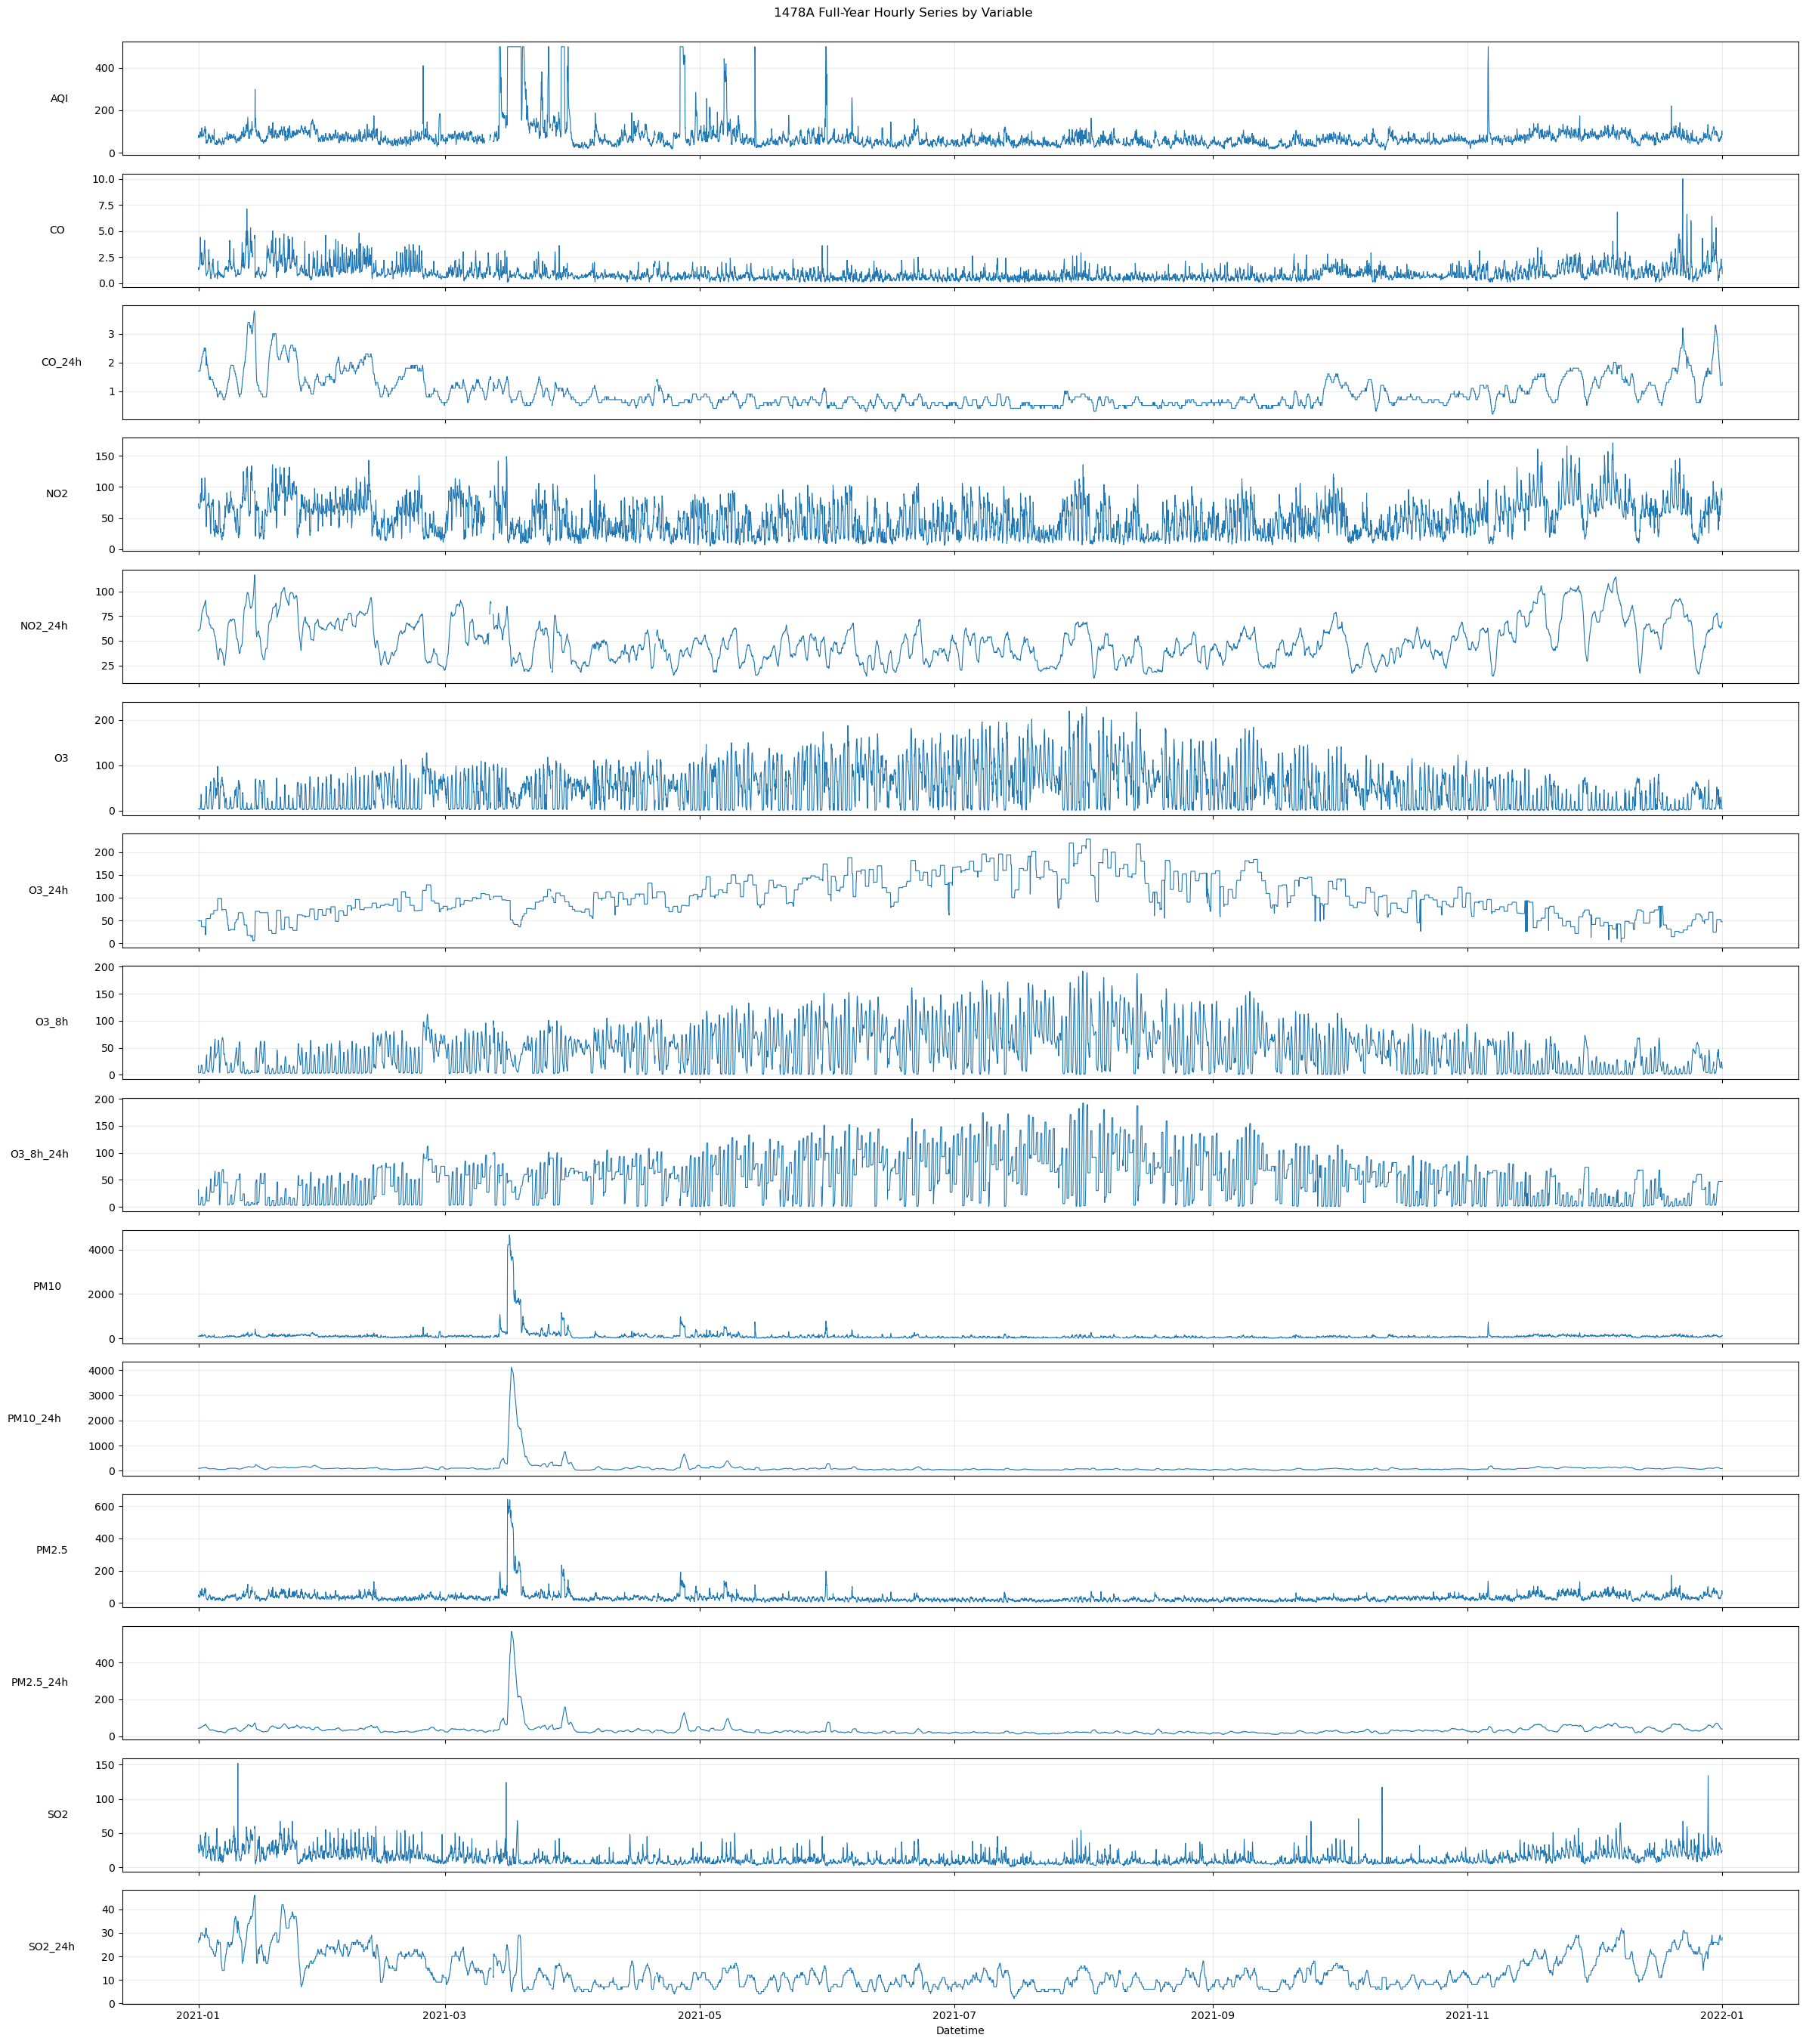

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder = "C:\\DOCUMENTO\\站点_20210101-20211231\\20210101-20211231"
site_file = os.path.join(folder, "1478A_biological_products_institute_yearly_wide.csv")

df = pd.read_csv(site_file)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")

variables = [
    "AQI", "CO", "CO_24h", "NO2", "NO2_24h", "O3", "O3_24h",
    "O3_8h", "O3_8h_24h", "PM10", "PM10_24h", "PM2.5", "PM2.5_24h",
    "SO2", "SO2_24h"
]
variables = [v for v in variables if v in df.columns]

fig, axes = plt.subplots(
    nrows=len(variables),
    ncols=1,
    figsize=(24, 1.8 * len(variables)),
    sharex=True,
)

if len(variables) == 1:
    axes = [axes]

for ax, var in zip(axes, variables):
    ax.plot(df["datetime"], df[var], linewidth=0.8)
    ax.set_ylabel(var, rotation=0, ha="right", va="center", labelpad=25)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Datetime")
fig.suptitle("1478A Full-Year Hourly Series by Variable", y=1.0)
plt.tight_layout()
plt.show()
